# Aluminum_New_Ipad — Dataset Audit

Notebook **tự chứa toàn bộ code phân tích**, không gọi file `.py` bên ngoài. Dataset nguồn không bị sửa hoặc di chuyển.

Quy ước chia dữ liệu: `train/good` và `test/good` đều được gán vào **train** qua cột `assigned_split`; các ảnh lỗi trong `test/<defect_group>` giữ ở **test**. Mask chuẩn hóa có `background=0`, `defect=1`; ảnh Good dùng zero mask.

## 1. Cấu hình và thư viện

Nếu notebook được mở từ thư mục dự án `E:/Project/TTTN`, không cần đổi `PROJECT_ROOT`.

In [ ]:
from pathlib import Path
from collections import defaultdict
from itertools import combinations
import hashlib
import json
import math
import shutil

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATASET_ROOT = PROJECT_ROOT / 'data' / '3cad_ani'
OUTPUT_DIR = DATASET_ROOT / 'dataset_audit'
MASK_OUTPUT_DIR = OUTPUT_DIR / 'binary_masks'
VIZ_DIR = OUTPUT_DIR / 'visualizations'
IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.webp'}
NEAR_DUPLICATE_HAMMING_THRESHOLD = 4

assert DATASET_ROOT.is_dir(), f'Không tìm thấy dataset: {DATASET_ROOT}'
print('Dataset:', DATASET_ROOT)
print('Output :', OUTPUT_DIR)

Dataset: E:\Project\TTTN\data\3cad_ani
Output : E:\Project\TTTN\data\3cad_ani\dataset_audit


## 2. Hàm tiện ích

Cell này định nghĩa cách đọc ảnh an toàn, hash ảnh, chuẩn hóa mask, thống kê phân vị và morphology.

In [2]:
def image_files(folder):
    if not folder.exists():
        return []
    return sorted(p for p in folder.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTS)


def read_rgb(path):
    try:
        with Image.open(path) as check:
            check.verify()
        with Image.open(path) as image:
            return np.asarray(image.convert('RGB')), ''
    except (UnidentifiedImageError, OSError, ValueError, SyntaxError) as exc:
        return None, f'{type(exc).__name__}: {exc}'


def file_sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


def difference_hash(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    small = cv2.resize(gray, (9, 8), interpolation=cv2.INTER_AREA)
    bits = (small[:, 1:] > small[:, :-1]).reshape(-1)
    return f"{sum(int(v) << i for i, v in enumerate(bits)):016x}"


def hamming_distance(hash_a, hash_b):
    return (int(hash_a, 16) ^ int(hash_b, 16)).bit_count()


def five_number(values):
    values = pd.Series(values).dropna().astype(float)
    if values.empty:
        return dict.fromkeys(['min', 'q1', 'median', 'q3', 'max'], np.nan)
    q = values.quantile([0, .25, .5, .75, 1]).tolist()
    return dict(zip(['min', 'q1', 'median', 'q3', 'max'], q))


def classify_component(component_mask, width, height, area):
    contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_area = sum(cv2.contourArea(c) for c in contours)
    hull_area = sum(cv2.contourArea(cv2.convexHull(c)) for c in contours) if contours else 0
    solidity = contour_area / hull_area if hull_area else 1.0
    long_short_ratio = max(width / height, height / width) if min(width, height) else np.inf
    extent = area / (width * height)
    if long_short_ratio >= 3:
        morphology = 'elongated_horizontal' if width >= height else 'elongated_vertical'
    elif solidity >= .80 and extent >= .60:
        morphology = 'compact'
    else:
        morphology = 'irregular'
    return long_short_ratio, extent, solidity, morphology


def relative(path):
    return path.relative_to(DATASET_ROOT).as_posix()

## 3. Kiểm tra nhanh cấu trúc nguồn

Chỉ đếm file ảnh, chưa ghi output.

In [3]:
source_folders = [DATASET_ROOT / 'train' / 'good', DATASET_ROOT / 'test' / 'good']
source_folders += sorted(p for p in (DATASET_ROOT / 'test').iterdir() if p.is_dir() and p.name.lower() != 'good')
source_counts = pd.DataFrame([
    {'source_folder': relative(folder), 'image_files': len(image_files(folder))}
    for folder in source_folders
])
display(source_counts)

,source_folder,image_files
0,train/good,2233
1,test/good,999
2,test/bruise,117
3,test/bump,3425
4,test/knife mark,21
5,test/Multiple-defects,97
6,test/scratche,277


## 4. Quét ảnh, QC và chuẩn hóa mask

Chạy lại cell này sẽ tạo mới **chỉ thư mục** `data/3cad_ani/dataset_audit`. Ảnh/mask nguồn không bị thay đổi.

In [4]:
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
MASK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

sources = []
for original_split in ('train', 'test'):
    for image_path in image_files(DATASET_ROOT / original_split / 'good'):
        sources.append((image_path, 'Good', 'good', original_split, 'train', None))

for group_dir in sorted(p for p in (DATASET_ROOT / 'test').iterdir() if p.is_dir() and p.name.lower() != 'good'):
    for image_path in image_files(group_dir):
        mask_path = DATASET_ROOT / 'ground_truth' / group_dir.name / image_path.name
        sources.append((image_path, 'Defect', group_dir.name, 'test', 'test', mask_path))

manifest_rows = []
component_rows = []
representative_paths = defaultdict(list)

for index, (image_path, label, group, original_split, assigned_split, mask_path) in enumerate(sources, 1):
    image_id = f"{label.lower()}_{group}_{image_path.stem}_{hashlib.md5(str(image_path).encode()).hexdigest()[:8]}"
    row = {
        'image_id': image_id, 'image_path': relative(image_path),
        'original_split': original_split, 'assigned_split': assigned_split,
        'label': label, 'defect_group': group, 'image_read_error': '',
        'mask_source_path': relative(mask_path) if mask_path else '',
        'mask_missing': False, 'mask_read_error': '', 'size_mismatch': False,
        'image_height': np.nan, 'image_width': np.nan, 'aspect_ratio_w_h': np.nan,
        'sha256': '', 'dhash': '', 'normalized_mask_path': '',
        'defect_pixels': np.nan, 'defect_ratio': np.nan, 'num_components': np.nan,
    }
    rgb, image_error = read_rgb(image_path)
    if rgb is None:
        row['image_read_error'] = image_error
        manifest_rows.append(row)
        continue

    height, width = rgb.shape[:2]
    row.update(image_height=height, image_width=width, aspect_ratio_w_h=width / height,
               sha256=file_sha256(image_path), dhash=difference_hash(rgb))

    if label == 'Good':
        binary_mask = np.zeros((height, width), dtype=np.uint8)
    elif not mask_path.exists():
        row['mask_missing'] = True
        manifest_rows.append(row)
        continue
    else:
        raw_mask, mask_error = read_rgb(mask_path)
        if raw_mask is None:
            row['mask_read_error'] = mask_error
            manifest_rows.append(row)
            continue
        if raw_mask.shape[:2] != (height, width):
            row['size_mismatch'] = True
            row['mask_read_error'] = f"image={width}x{height}; mask={raw_mask.shape[1]}x{raw_mask.shape[0]}"
            manifest_rows.append(row)
            continue
        binary_mask = np.any(raw_mask != 0, axis=2).astype(np.uint8)

    normalized_path = MASK_OUTPUT_DIR / group / f'{image_id}.png'
    normalized_path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(binary_mask).save(normalized_path)
    defect_pixels = int(binary_mask.sum())
    row.update(normalized_mask_path=relative(normalized_path), defect_pixels=defect_pixels,
               defect_ratio=defect_pixels / (height * width))

    if label == 'Defect':
        count, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
        row['num_components'] = count - 1
        for component_id in range(1, count):
            left, top, comp_width, comp_height, area = map(int, stats[component_id])
            component_mask = (labels[top:top+comp_height, left:left+comp_width] == component_id).astype(np.uint8)
            aspect, extent, solidity, morphology = classify_component(
                component_mask, comp_width, comp_height, area
            )
            component_rows.append({
                'image_id': image_id, 'image_path': relative(image_path), 'defect_group': group,
                'component_id': component_id, 'area_pixels': area, 'left': left, 'top': top,
                'width': comp_width, 'height': comp_height,
                'aspect_ratio_long_short': aspect, 'bbox_extent': extent, 'solidity': solidity,
                'morphology': morphology, 'centroid_x': float(centroids[component_id][0]),
                'centroid_y': float(centroids[component_id][1]),
            })
        if len(representative_paths[group]) < 2:
            representative_paths[group].append((image_path, normalized_path))

    manifest_rows.append(row)
    if index % 100 == 0 or index == len(sources):
        print(f'Processed {index}/{len(sources)}')

manifest = pd.DataFrame(manifest_rows)
components = pd.DataFrame(component_rows)
manifest.to_csv(OUTPUT_DIR / 'manifest.csv', index=False, encoding='utf-8-sig')
components.to_csv(OUTPUT_DIR / 'components.csv', index=False, encoding='utf-8-sig')
print(f'Done: {len(manifest)} images, {len(components)} defect components')

Processed 100/7169
Processed 200/7169
Processed 300/7169
Processed 400/7169
Processed 500/7169
Processed 600/7169
Processed 700/7169
Processed 800/7169
Processed 900/7169
Processed 1000/7169
Processed 1100/7169
Processed 1200/7169
Processed 1300/7169
Processed 1400/7169
Processed 1500/7169
Processed 1600/7169
Processed 1700/7169
Processed 1800/7169
Processed 1900/7169
Processed 2000/7169
Processed 2100/7169
Processed 2200/7169
Processed 2300/7169
Processed 2400/7169
Processed 2500/7169
Processed 2600/7169
Processed 2700/7169
Processed 2800/7169
Processed 2900/7169
Processed 3000/7169
Processed 3100/7169
Processed 3200/7169
Processed 3300/7169
Processed 3400/7169
Processed 3500/7169
Processed 3600/7169
Processed 3700/7169
Processed 3800/7169
Processed 3900/7169
Processed 4000/7169
Processed 4100/7169
Processed 4200/7169
Processed 4300/7169
Processed 4400/7169
Processed 4500/7169
Processed 4600/7169
Processed 4700/7169
Processed 4800/7169
Processed 4900/7169
Processed 5000/7169
Processed

## 5. Duplicate và leakage

- Exact duplicate: SHA-256 giống nhau.
- Near duplicate: dHash 64-bit có Hamming distance ≤ ngưỡng cấu hình. Đây là danh sách ứng viên cần xem lại, không tự động kết luận là duplicate.
- Cột `cross_split=True` đánh dấu nguy cơ leakage giữa train và test.

In [5]:
valid_hashes = manifest[manifest['sha256'].ne('')].copy()
exact_duplicates = valid_hashes[valid_hashes.duplicated('sha256', keep=False)].sort_values(['sha256', 'image_path'])
exact_duplicates['cross_split_group'] = exact_duplicates.groupby('sha256')['assigned_split'].transform('nunique').gt(1)
exact_duplicates.to_csv(OUTPUT_DIR / 'exact_duplicates.csv', index=False, encoding='utf-8-sig')

near_columns = ['image_id_a', 'path_a', 'split_a', 'label_a', 'image_id_b', 'path_b', 'split_b', 'label_b',
                'hamming_distance', 'cross_split']
near_rows = []
hash_rows = valid_hashes[['image_id', 'image_path', 'assigned_split', 'label', 'dhash']].to_dict('records')
for item_a, item_b in combinations(hash_rows, 2):
    distance = hamming_distance(item_a['dhash'], item_b['dhash'])
    if distance <= NEAR_DUPLICATE_HAMMING_THRESHOLD:
        near_rows.append({
            'image_id_a': item_a['image_id'], 'path_a': item_a['image_path'],
            'split_a': item_a['assigned_split'], 'label_a': item_a['label'],
            'image_id_b': item_b['image_id'], 'path_b': item_b['image_path'],
            'split_b': item_b['assigned_split'], 'label_b': item_b['label'],
            'hamming_distance': distance,
            'cross_split': item_a['assigned_split'] != item_b['assigned_split'],
        })
near_duplicates = pd.DataFrame(near_rows, columns=near_columns)
near_duplicates.to_csv(OUTPUT_DIR / 'near_duplicate_candidates_dhash_le4.csv', index=False, encoding='utf-8-sig')

print('Exact duplicate images:', len(exact_duplicates))
print('Near-duplicate pairs   :', len(near_duplicates))
print('Cross-split candidates:', int(near_duplicates['cross_split'].sum()) if len(near_duplicates) else 0)

Exact duplicate images: 2
Near-duplicate pairs   : 1698805
Cross-split candidates: 795051


## 6. Bảng thống kê và báo cáo

In [6]:
resolution_statistics = pd.DataFrame([
    {'metric': metric, **five_number(manifest[column])}
    for metric, column in [('height', 'image_height'), ('width', 'image_width'),
                           ('aspect_ratio_w_h', 'aspect_ratio_w_h')]
])
resolution_statistics.to_csv(OUTPUT_DIR / 'resolution_statistics.csv', index=False)

defect_images = manifest[(manifest['label'] == 'Defect') & manifest['defect_pixels'].notna()].copy()
defect_area_statistics = pd.DataFrame([
    {'defect_group': group, 'images': len(table),
     **{f'defect_pixels_{key}': value for key, value in five_number(table['defect_pixels']).items()},
     **{f'defect_ratio_{key}': value for key, value in five_number(table['defect_ratio']).items()},
     'components_total': int(table['num_components'].sum())}
    for group, table in defect_images.groupby('defect_group')
])
defect_area_statistics.to_csv(OUTPUT_DIR / 'defect_image_area_statistics_by_group.csv', index=False)

component_statistics = pd.DataFrame([
    {'metric': column, **five_number(components[column])}
    for column in ['area_pixels', 'width', 'height']
]) if len(components) else pd.DataFrame(columns=['metric', 'min', 'q1', 'median', 'q3', 'max'])
component_statistics.to_csv(OUTPUT_DIR / 'component_size_statistics.csv', index=False)
morphology_counts = (components.groupby(['defect_group', 'morphology']).size().rename('components').reset_index()
                     if len(components) else pd.DataFrame(columns=['defect_group', 'morphology', 'components']))
morphology_counts.to_csv(OUTPUT_DIR / 'component_morphology_counts.csv', index=False)

summary = {
    'total_images': int(len(manifest)),
    'good_images_assigned_train': int((manifest['label'] == 'Good').sum()),
    'defect_images_assigned_test': int((manifest['label'] == 'Defect').sum()),
    'image_read_errors': int(manifest['image_read_error'].ne('').sum()),
    'missing_masks': int(manifest['mask_missing'].sum()),
    'unreadable_masks': int((manifest['mask_read_error'].ne('') & ~manifest['size_mismatch']).sum()),
    'image_mask_size_mismatches': int(manifest['size_mismatch'].sum()),
    'valid_normalized_masks': int(manifest['normalized_mask_path'].ne('').sum()),
    'exact_duplicate_images': int(len(exact_duplicates)),
    'near_duplicate_pairs_dhash_le4': int(len(near_duplicates)),
    'near_duplicate_cross_split_pairs': int(near_duplicates['cross_split'].sum()) if len(near_duplicates) else 0,
    'total_defect_components': int(len(components)),
    'smallest_component_area_pixels': int(components['area_pixels'].min()) if len(components) else None,
    'smallest_component_width_pixels': int(components['width'].min()) if len(components) else None,
    'smallest_component_height_pixels': int(components['height'].min()) if len(components) else None,
    'split_policy': 'train/good + test/good -> assigned_split=train; defect images remain test',
    'mask_standard': 'background=0, defect=1; Good uses all-zero mask',
}
(OUTPUT_DIR / 'summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')

report_lines = ['# Aluminum_New_Ipad dataset audit', '', '## Summary', '']
report_lines += [f'- **{key}**: {value}' for key, value in summary.items()]
report_lines += ['', 'Near-duplicate là ứng viên cần kiểm tra trực quan, không phải kết luận tự động.', '']
(OUTPUT_DIR / 'REPORT.md').write_text('\n'.join(report_lines), encoding='utf-8')
display(pd.DataFrame(summary.items(), columns=['metric', 'value']))

,metric,value
0,total_images,7169
1,good_images_assigned_train,3232
2,defect_images_assigned_test,3937
3,image_read_errors,0
4,missing_masks,0
5,unreadable_masks,0
6,image_mask_size_mismatches,0
7,valid_normalized_masks,7169
8,exact_duplicate_images,2
9,near_duplicate_pairs_dhash_le4,1698805


## 7. Visualization đại diện

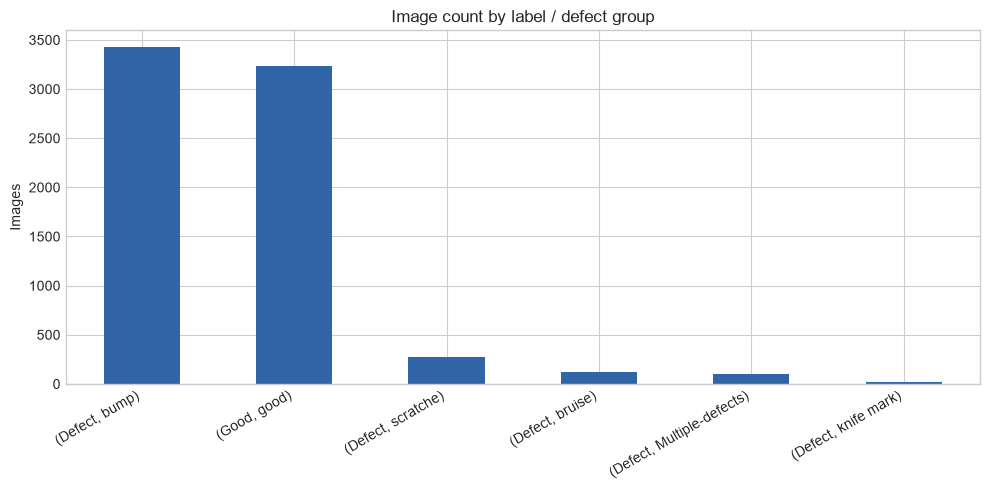

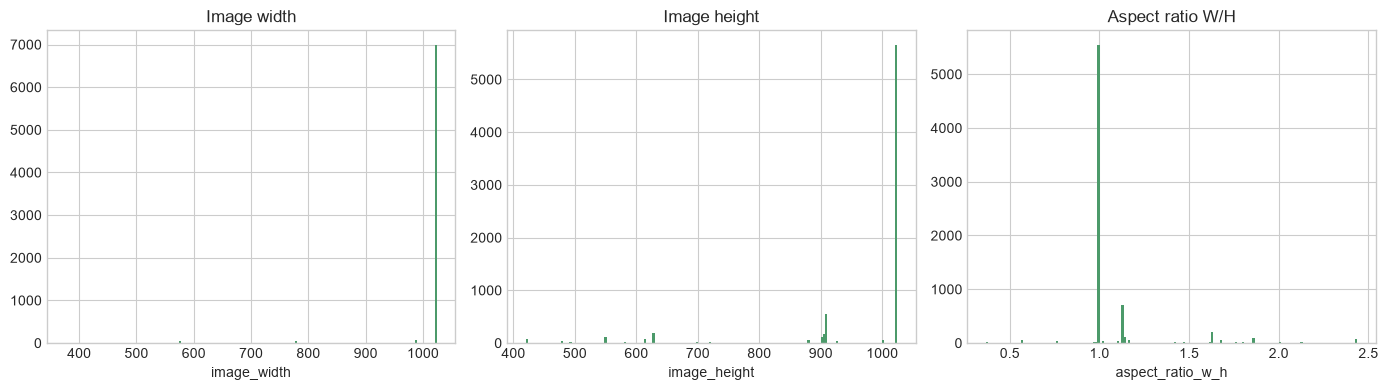

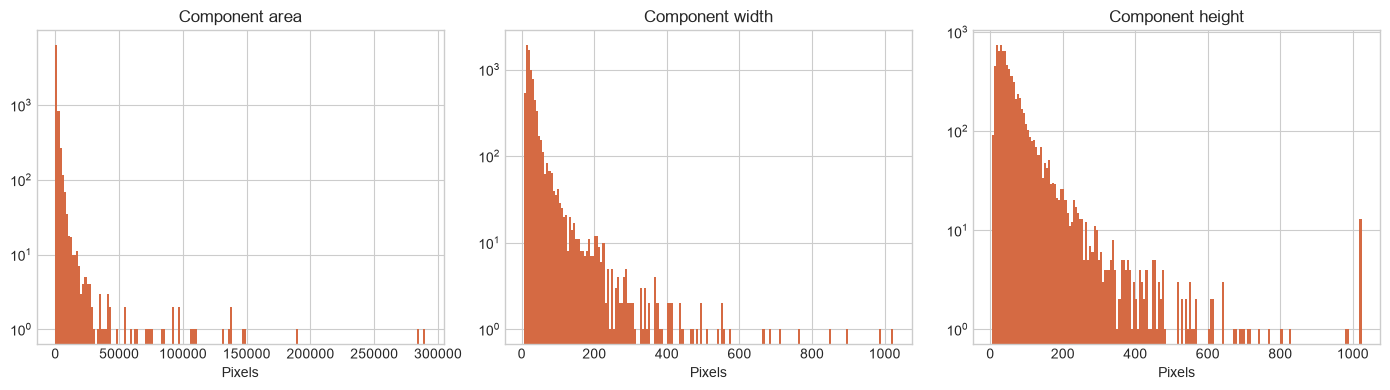

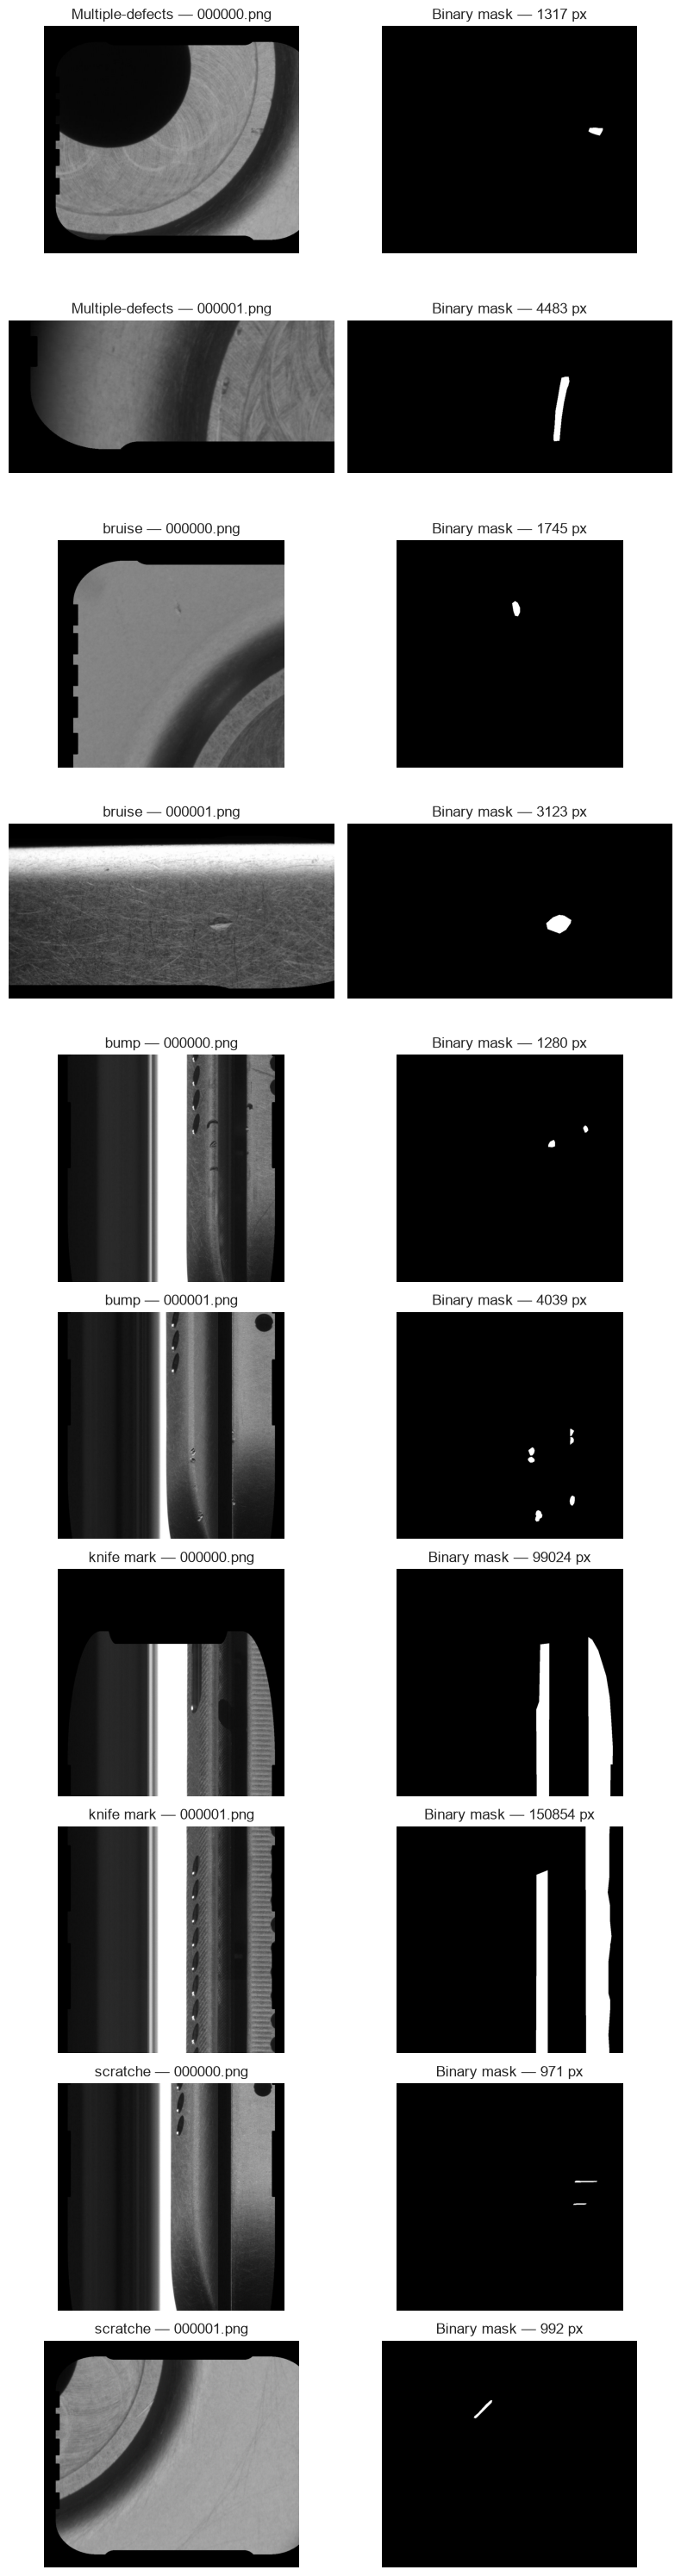

In [7]:
plt.style.use('seaborn-v0_8-whitegrid')
counts = manifest.groupby(['label', 'defect_group']).size().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
counts.plot.bar(ax=ax, color='#3264a8')
ax.set(title='Image count by label / defect group', xlabel='', ylabel='Images')
plt.xticks(rotation=30, ha='right')
fig.tight_layout(); fig.savefig(VIZ_DIR / 'image_counts.png', dpi=180); plt.show()

valid_resolution = manifest.dropna(subset=['image_height', 'image_width'])
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, column, title in zip(axes, ['image_width', 'image_height', 'aspect_ratio_w_h'],
                             ['Image width', 'Image height', 'Aspect ratio W/H']):
    ax.hist(valid_resolution[column], bins='auto', color='#4c9a6a')
    ax.set(title=title, xlabel=column)
fig.tight_layout(); fig.savefig(VIZ_DIR / 'resolution_distribution.png', dpi=180); plt.show()

if len(components):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, column, title in zip(axes, ['area_pixels', 'width', 'height'],
                                 ['Component area', 'Component width', 'Component height']):
        ax.hist(components[column], bins='auto', color='#d56a43')
        ax.set(title=title, xlabel='Pixels', yscale='log')
    fig.tight_layout(); fig.savefig(VIZ_DIR / 'component_size_distributions.png', dpi=180); plt.show()

representatives = [(group, pair) for group in sorted(representative_paths) for pair in representative_paths[group]]
if representatives:
    fig, axes = plt.subplots(len(representatives), 2, figsize=(8, 3 * len(representatives)), squeeze=False)
    for row_index, (group, (image_path, mask_path)) in enumerate(representatives):
        image = np.asarray(Image.open(image_path).convert('RGB'))
        mask = np.asarray(Image.open(mask_path))
        axes[row_index, 0].imshow(image)
        axes[row_index, 0].set_title(f'{group} — {image_path.name}')
        axes[row_index, 1].imshow(mask, cmap='gray', vmin=0, vmax=1)
        axes[row_index, 1].set_title(f'Binary mask — {int(mask.sum())} px')
        axes[row_index, 0].axis('off'); axes[row_index, 1].axis('off')
    fig.tight_layout(); fig.savefig(VIZ_DIR / 'representative_images_and_masks.png', dpi=180); plt.show()

## 8. Xem các bảng quan trọng và tiny defects

In [8]:
print('Số ảnh theo split / label / defect group')
display(manifest.groupby(['assigned_split', 'label', 'defect_group']).size().rename('images').reset_index())

print('QC issues')
qc_issues = manifest[
    manifest['image_read_error'].ne('') | manifest['mask_missing'] |
    manifest['mask_read_error'].ne('') | manifest['size_mismatch']
]
display(qc_issues[['image_path', 'image_read_error', 'mask_source_path',
                   'mask_missing', 'mask_read_error', 'size_mismatch']])

print('Resolution statistics')
display(resolution_statistics)
print('Defect area statistics by group')
display(defect_area_statistics)
print('Component statistics')
display(component_statistics)
display(morphology_counts)

if len(components):
    print('Tiny defect distribution (including 1% and 5% quantiles)')
    display(components[['area_pixels', 'width', 'height']].describe(
        percentiles=[.01, .05, .25, .50, .75, .95, .99]
    ))
    print('20 components nhỏ nhất')
    display(components.nsmallest(20, 'area_pixels')[
        ['image_path', 'defect_group', 'area_pixels', 'width', 'height', 'morphology']
    ])

print('Exact duplicates')
display(exact_duplicates.head(30))
print('Near-duplicate candidates')
display(near_duplicates.sort_values(['cross_split', 'hamming_distance'], ascending=[False, True]).head(30))

Số ảnh theo split / label / defect group


,assigned_split,label,defect_group,images
0,test,Defect,Multiple-defects,97
1,test,Defect,bruise,117
2,test,Defect,bump,3425
3,test,Defect,knife mark,21
4,test,Defect,scratche,277
5,train,Good,good,3232


QC issues


,image_path,image_read_error,mask_source_path,mask_missing,mask_read_error,size_mismatch


Resolution statistics


...

,image_path,defect_group,area_pixels,width,height,morphology
1936,test/bump/000910.png,bump,22,10,4,irregular
6436,test/bump/003023.png,bump,27,8,6,irregular
6508,test/bump/003055.png,bump,29,8,5,compact
79,test/bruise/000027.png,bruise,31,7,8,irregular
7305,test/Multiple-defects/000040.png,Multiple-defects,32,7,9,irregular
4538,test/bump/002137.png,bump,33,6,7,compact
4542,test/bump/002138.png,bump,33,6,7,compact
2219,test/bump/001053.png,bump,35,8,7,compact
2595,test/bump/001192.png,bump,38,7,8,compact
4093,test/bump/001961.png,bump,39,6,8,compact


Exact duplicates


,image_id,image_path,original_split,assigned_split,label,defect_group,image_read_error,mask_source_path,mask_missing,mask_read_error,...,image_height,image_width,aspect_ratio_w_h,sha256,dhash,normalized_mask_path,defect_pixels,defect_ratio,num_components,cross_split_group
4889,defect_bump_001540_d9afaedd,test/bump/001540.png,test,test,Defect,bump,,ground_truth/bump/001540.png,False,,...,910,1024,1.125275,8c8c9c69b03653eeeb7d5d79b766c596231adfa6755831...,410301c563311159,dataset_audit/binary_masks/bump/defect_bump_00...,1079,0.001158,1.0,False
4890,defect_bump_001541_68d16fd8,test/bump/001541.png,test,test,Defect,bump,,ground_truth/bump/001541.png,False,,...,910,1024,1.125275,8c8c9c69b03653eeeb7d5d79b766c596231adfa6755831...,410301c563311159,dataset_audit/binary_masks/bump/defect_bump_00...,1131,0.001214,1.0,False


Near-duplicate candidates


,image_id_a,path_a,split_a,label_a,image_id_b,path_b,split_b,label_b,hamming_distance,cross_split
543,good_good_000000_70a7f05d,train/good/000000.png,train,Good,defect_bump_001299_1eb30baf,test/bump/001299.png,test,Defect,0,True
661,good_good_000000_70a7f05d,train/good/000000.png,train,Good,defect_bump_002234_de10bfa8,test/bump/002234.png,test,Defect,0,True
840,good_good_000000_70a7f05d,train/good/000000.png,train,Good,defect_bump_003109_37fbbacc,test/bump/003109.png,test,Defect,0,True
845,good_good_000000_70a7f05d,train/good/000000.png,train,Good,defect_bump_003129_c1652cac,test/bump/003129.png,test,Defect,0,True
846,good_good_000000_70a7f05d,train/good/000000.png,train,Good,defect_bump_003133_7c92c41a,test/bump/003133.png,test,Defect,0,True
848,good_good_000000_70a7f05d,train/good/000000.png,train,Good,defect_bump_003142_9fed1ac3,test/bump/003142.png,test,Defect,0,True
914,good_good_000000_70a7f05d,train/good/000000.png,train,Good,defect_Multiple-defects_000038_07b541e1,test/Multiple-defects/000038.png,test,Defect,0,True
945,good_good_000000_70a7f05d,train/good/000000.png,train,Good,defect_scratche_000079_75cf676a,test/scratche/000079.png,test,Defect,0,True
961,good_good_000000_70a7f05d,train/good/000000.png,train,Good,defect_scratche_000177_a6da1023,test/scratche/000177.png,test,Defect,0,True
978,good_good_000000_70a7f05d,train/good/000000.png,train,Good,defect_scratche_000265_3f1b826e,test/scratche/000265.png,test,Defect,0,True


## Output

Sau khi chạy hết notebook, kết quả nằm trong `data/3cad_ani/dataset_audit/`:

- `manifest.csv`: một dòng cho mỗi ảnh.
- `components.csv`: một dòng cho mỗi connected component.
- `binary_masks/`: mask 0/1 đã chuẩn hóa, gồm zero mask cho Good.
- Các bảng CSV thống kê, duplicate/leakage, `summary.json`, `REPORT.md`.
- `visualizations/`: các biểu đồ và ảnh/mask đại diện.